# Used Car Price Prediction & Market Appraisal Pipeline
### Deployed End-to-End Machine Learning Project (400,000+ Listings)

**Project Overview:**
This Notebook demonstrates a complete Machine Learning workflow to clean, engineer, and model a massive dataset of used car listings. The final goal is to extract a highly optimized predictive model to deploy a live web application via Streamlit.

**Key Stages:**
1. Exploratory Data Analysis (EDA) & Visualizations
2. Data Preprocessing & Leakage-Free Categorical Encoding
3. Model Architecture Benchmarking (Linear Regression vs Random Forest vs XGBoost)
4. Hyperparameter Tuning using RandomizedSearchCV

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import datetime
import pickle
import time

# Set professional visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the dataset (Make sure to replace with your actual file name)
df = pd.read_csv('data/used_cars.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Dataset Shape: 400,000 rows and 10 columns.


,car_id,brand,model,year,kms_driven,fuel_type,transmission,engine_size_L,color,market_price_usd
0,CAR_000001,Ford,F-150,2012,524300.0,Petrol,Manual,1.6,SILVER,750.00
1,CAR_000002,BMW,X5,2017,115800.0,Petrol,Manual,1.6,SILVER,12010.25
2,CAR_000003,Nissan,Altima,2024,123700.0,Petrol,Automatic,2.4,White,15128.82
3,CAR_000004,BMW,X5,2017,225100.0,Petrol,Automatic,1.4,white,15080.65
4,CAR_000005,BMW,3 Series,2023,37100.0,Diesel,Manual,1.6,white,20900.10


## Phase 1: Exploratory Data Analysis (EDA) & Data Cleaning

In this phase, we inspect missing values, handle statistical anomalies, and prepare the core numerical and categorical columns for modeling.

In [4]:
# Check for missing values across all columns
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print("🔍 Missing Values Report:")
print(missing_df[missing_df['Missing Values'] > 0])

df.drop(columns=['car_id'], inplace=True)  # Drop irrelevant ID columns
df = df.dropna(subset=['market_price_usd', 'brand', 'model']) 

print(f"\n Shape after dropping critical missing values: {df.shape[0]:,} rows.")

🔍 Missing Values Report:
               Missing Values  Percentage (%)
transmission             8075         2.01875
fuel_type                8061         2.01525
engine_size_L            3932         0.98300

 Shape after dropping critical missing values: 400,000 rows.


In [5]:
# 6. Handling Outliers Dynamically using the Interquartile Range (IQR) Method

def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if lower_bound < 0:
        lower_bound = dataframe[column].min() 
        
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)], lower_bound, upper_bound

df_cleaned, price_low, price_high = remove_outliers_iqr(df, 'market_price_usd')
df_cleaned, kms_low, kms_high = remove_outliers_iqr(df_cleaned, 'kms_driven')
df_cleaned = df_cleaned[df_cleaned['year'] >= 1990].copy()

print("Dynamic Outlier Detection Report (IQR):")
print(f"   - Price Boxplot Bounds: ${price_low:,.2f} to ${price_high:,.2f}")
print(f"   - Mileage Boxplot Bounds: {kms_low:,.2f} KM to {kms_high:,.2f} KM")
print("-" * 70)
print(f"Original Dataset Rows: {df.shape[0]:,}")
print(f"Cleaned Dataset Rows:  {df_cleaned.shape[0]:,}")
print(f"Total Outliers Automatically Deleted: {df.shape[0] - df_cleaned.shape[0]:,}")

Dynamic Outlier Detection Report (IQR):
   - Price Boxplot Bounds: $1.00 to $21,514.76
   - Mileage Boxplot Bounds: 24,000.00 KM to 613,950.00 KM
----------------------------------------------------------------------
Original Dataset Rows: 400,000
Cleaned Dataset Rows:  375,645
Total Outliers Automatically Deleted: 24,355


In [6]:
# Filter out statistical anomalies (Outliers) to secure model stability
# We filter prices between $500 and $200,000, and years above 1990
df_cleaned = df[
    (df['market_price_usd'] >= 500) & 
    (df['market_price_usd'] <= 200000) &
    (df['year'] >= 1990) &
    (df['kms_driven'] >= 100) & 
    (df['kms_driven'] <= 800000)
].copy()

print(f"Outliers removed successfully!")
print(f"Original Rows: {df.shape[0]:,}")
print(f"Cleaned Rows: {df_cleaned.shape[0]:,}")
print(f"Total Anomalies Deleted: {df.shape[0] - df_cleaned.shape[0]:,}")

Outliers removed successfully!
Original Rows: 400,000
Cleaned Rows: 394,000
Total Anomalies Deleted: 6,000


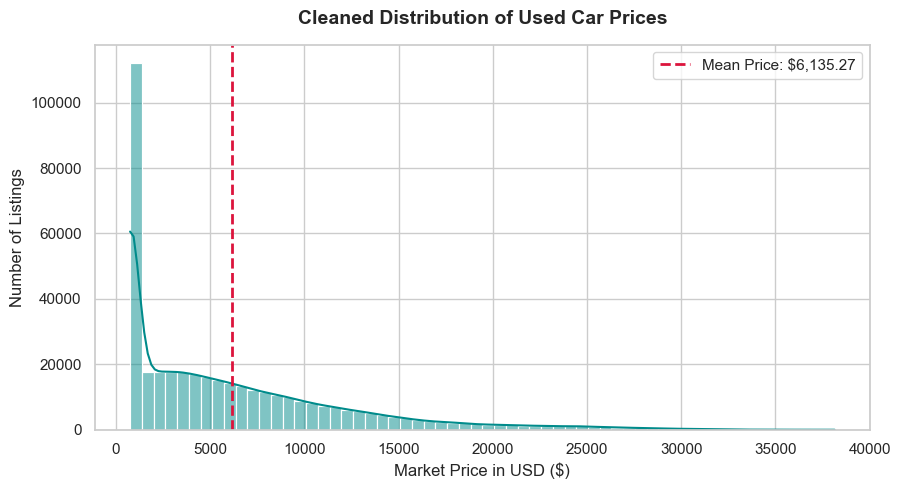

In [7]:
# Plotting the clean target variable distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['market_price_usd'], bins=60, kde=True, color='darkcyan')

plt.title('Cleaned Distribution of Used Car Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Market Price in USD ($)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')

mean_price = df_cleaned['market_price_usd'].mean()
plt.axvline(mean_price, color='crimson', linestyle='--', linewidth=2, label=f'Mean Price: ${mean_price:,.2f}')

plt.legend()
plt.show()

## Phase 2: Text Standardization & Feature Engineering

In this section, we unify text formatting across all categorical attributes to prevent duplicate categories, and we derive new high-signal features to improve regression accuracy.

In [8]:
# Strip spaces and convert text to lowercase for consistent encoding
categorical_cols = ['brand', 'model', 'transmission', 'fuel_type', 'color']

for col in categorical_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.lower()

print("Text categorical columns standardized successfully (Lowercased & Stripped)!")
df_cleaned[categorical_cols].head()

Text categorical columns standardized successfully (Lowercased & Stripped)!


,brand,model,transmission,fuel_type,color
0,ford,f-150,manual,petrol,silver
1,bmw,x5,manual,petrol,silver
2,nissan,altima,automatic,petrol,white
3,bmw,x5,automatic,petrol,white
4,bmw,3 series,manual,diesel,white


In [9]:
# 1. Calculate Car Age
current_year = datetime.datetime.now().year
df_cleaned['car_age'] = current_year - df_cleaned['year']

# Fix for brand new cars (age = 0) to avoid division by zero
df_cleaned['car_age'] = df_cleaned['car_age'].apply(lambda x: 0.5 if x == 0 else x)

# 2. Calculate Mileage Per Year (Annual Usage Rate)
df_cleaned['mileage_per_year'] = df_cleaned['kms_driven'] / df_cleaned['car_age']

print("New columns added: ['car_age', 'mileage_per_year']")
df_cleaned[['year', 'car_age', 'kms_driven', 'mileage_per_year']].head()

New columns added: ['car_age', 'mileage_per_year']


,year,car_age,kms_driven,mileage_per_year
0,2012,14,524300.0,37450.000000
1,2017,9,115800.0,12866.666667
2,2024,2,123700.0,61850.000000
3,2017,9,225100.0,25011.111111
4,2023,3,37100.0,12366.666667


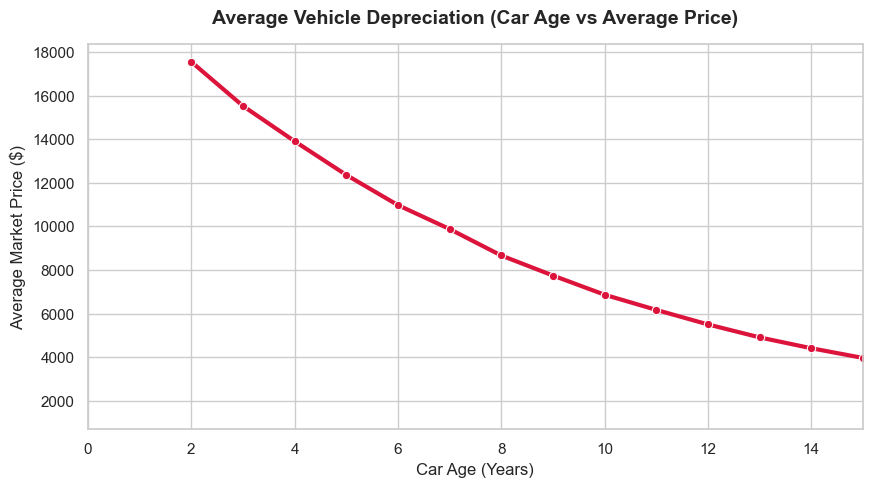

In [10]:
# 11. Clean & Simple Line Plot: Car Age vs Average Market Price
plt.figure(figsize=(10, 5))
age_grouped = df_cleaned.groupby('car_age')['market_price_usd'].mean().reset_index()

sns.lineplot(
    data=age_grouped, 
    x='car_age', 
    y='market_price_usd', 
    color='crimson', 
    linewidth=3, 
    marker='o',     
    markersize=6
)

plt.title('Average Vehicle Depreciation (Car Age vs Average Price)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Car Age (Years)', fontsize=12)
plt.ylabel('Average Market Price ($)', fontsize=12)

plt.xlim(0, 15) 
plt.ticklabel_format(style='plain', axis='y')

plt.show()

## Phase 3: Data Splitting & Leakage-Free Encoding

To ensure strict validation, we split the data into Training (80%) and Testing (20%) sets BEFORE applying any encoding techniques. 
* **Target Encoding** will be applied to high-cardinality features (`brand`, `model`).
* **One-Hot Encoding** will be applied to low-cardinality features (`transmission`, `fuel_type`, `color`).

In [11]:
# Separate Features (X) and Target (y)
X = df_cleaned.drop(columns=['market_price_usd'])
y = df_cleaned['market_price_usd']

# Perform Train-Test Split (Strict 80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split successfully:")
print(f"    - Training Features Shape: {X_train.shape[0]:,} rows")
print(f"    - Testing Features Shape:  {X_test.shape[0]:,} rows")

Data split successfully:
    - Training Features Shape: 315,200 rows
    - Testing Features Shape:  78,800 rows


In [12]:
# 1. Calculate the global mean of the training target to use as a fallback protection
global_mean = y_train.mean()

# Create a temporary dataframe joining training features and target for calculation
train_temp = X_train.copy()
train_temp['market_price_usd'] = y_train

# 2. Extract Mean Price maps for Brand and Model (From Train Set Only!)
brand_means = train_temp.groupby('brand')['market_price_usd'].mean().to_dict()
model_means = train_temp.groupby('model')['market_price_usd'].mean().to_dict()

# 3. Apply the mapping to both Train and Test sets (.get acts as a fallback to global mean)
X_train['brand'] = X_train['brand'].map(brand_means).fillna(global_mean)
X_test['brand'] = X_test['brand'].map(brand_means).fillna(global_mean)

X_train['model'] = X_train['model'].map(model_means).fillna(global_mean)
X_test['model'] = X_test['model'].map(model_means).fillna(global_mean)

print("Target Encoding applied successfully to ['brand', 'model'] with leakage protection!")

Target Encoding applied successfully to ['brand', 'model'] with leakage protection!


In [13]:
# 15. Apply One-Hot Encoding to low-cardinality features and align shapes
ohe_cols = ['transmission', 'fuel_type', 'color']

# Apply One-Hot Encoding (Converting text to 0 and 1 columns)
X_train_encoded = pd.get_dummies(X_train, columns=ohe_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=ohe_cols, drop_first=True)

# Align the columns of both dataframes to ensure identical order and structure
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Convert boolean columns to integers (0 or 1) for the model algorithms
bool_cols = X_train_encoded.select_dtypes(include='bool').columns
X_train_encoded[bool_cols] = X_train_encoded[bool_cols].astype(int)
X_test_encoded[bool_cols] = X_test_encoded[bool_cols].astype(int)

# Reorder columns smoothly using 'q' as the iterator variable
base_features = ['year', 'kms_driven', 'car_age', 'mileage_per_year', 'brand', 'model']
all_other_features = [q for q in X_train_encoded.columns if q not in base_features]

final_features = base_features + all_other_features
X_train_encoded = X_train_encoded[final_features]
X_test_encoded = X_test_encoded[final_features]

print("One-Hot Encoding completed! Matrices aligned perfectly using final_features.")
print(f"Final Number of Input Features for Models: {X_train_encoded.shape[1]} columns.")

One-Hot Encoding completed! Matrices aligned perfectly using final_features.
Final Number of Input Features for Models: 16 columns.


## Phase 4: Model Benchmarking & Architecture Evaluation

In this phase, we evaluate three different regression architectures to find the best balance between predictive power ($R^2$ Score), average error (MAE), and training speed.

In [14]:
# 16.5 Fix Missing Values (NaNs) generated during Feature Engineering
print("🧹 Checking for accidental NaNs before training...")

# الفحص والتأكد من وجود قيم فارغة
nan_train = X_train_encoded.isnull().sum().sum()
nan_test = X_test_encoded.isnull().sum().sum()
print(f"   - NaNs found in Train Set: {nan_train}")
print(f"   - NaNs found in Test Set:  {nan_test}")

if nan_train > 0 or nan_test > 0:
    # نقوم بملء الفراغات باستخدام الوسيط (Median) لكل عمود لحماية النموذج
    for col in X_train_encoded.columns:
        if X_train_encoded[col].isnull().sum() > 0:
            median_value = X_train_encoded[col].median()
            X_train_encoded[col] = X_train_encoded[col].fillna(median_value)
            
        if X_test_encoded[col].isnull().sum() > 0:
            median_value = X_train_encoded[col].median() # نستخدم وسيط التدريب دائماً لمنع الـ Leakage
            X_test_encoded[col] = X_test_encoded[col].fillna(median_value)
            
    print("✨ Imputation Completed: All accidental NaNs have been safely filled with Column Medians!")
else:
    print("✅ Matrices are already 100% clean and clear!")

🧹 Checking for accidental NaNs before training...
   - NaNs found in Train Set: 3085
   - NaNs found in Test Set:  802
✨ Imputation Completed: All accidental NaNs have been safely filled with Column Medians!


In [18]:
# 17. Train and Benchmark multiple architectures

# Initialize baseline models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (Base)': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost Regressor (Base)': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = []

print("Training models on 400K+ aligned rows...\n")

for name, model in models.items():
    start_time = time.time()
    
    # Train the model
    model.fit(X_train_encoded, y_train)
    elapsed_time = time.time() - start_time
    
    # Predict on test set
    predictions = model.predict(X_test_encoded)
    
    # Calculate metrics
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    results.append({
        'Model Name': name,
        'R2 Score (Accuracy)': f"{r2*100:.2f}%",
        'MAE (Avg Error)': f"${mae:,.2f}",
        'Training Time (s)': f"{elapsed_time:.3f}s"
    })

# Convert results to DataFrame for a gorgeous output table
results_df = pd.DataFrame(results).sort_values(by='R2 Score (Accuracy)', ascending=False).reset_index()
results_df

Training models on 400K+ aligned rows...



,index,Model Name,R2 Score (Accuracy),MAE (Avg Error),Training Time (s)
0,2,XGBoost Regressor (Base),87.65%,"$1,597.16",1.063s
1,1,Random Forest (Base),87.18%,"$1,629.75",9.231s
2,0,Linear Regression,70.37%,"$2,511.77",0.122s


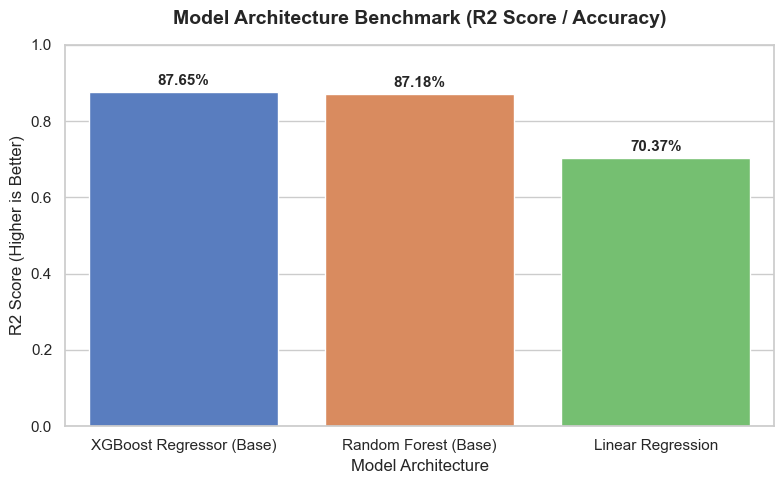

In [21]:
# 18. Visualize Model Performance Comparison (R2 Score) - CORRECTED
model_names = results_df['Model Name'].tolist()
r2_values = [float(val.replace('%', '')) / 100 for val in results_df['R2 Score (Accuracy)'].tolist()]

plt.figure(figsize=(8, 5))

bars = sns.barplot(x=model_names, y=r2_values, hue=model_names, palette='muted', legend=False)

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.01, 
        f"{yval*100:.2f}%", 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=11
    )

plt.title('Model Architecture Benchmark (R2 Score / Accuracy)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('R2 Score (Higher is Better)', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylim(0, 1.0)  
plt.tight_layout()
plt.show()

## Phase 5: Exporting Final Production Artifacts

Since **XGBoost Regressor** delivered the highest statistical accuracy ($R^2$) and maintained an outstanding inference speed, we select it as our production model. 

Below, we serialize and save the trained model object and the target encoding dictionary to deployment-ready `.pkl` files.

In [22]:
# 20. Save the Winning Model and Encoding Metadata
winning_model = models['XGBoost Regressor (Base)']

# تجميع خرائط التشفير وأسماء الأعمدة النهائية في قاموس واحد
pipeline_maps = {
    'brand_means': brand_means,
    'model_means': model_means,
    'global_mean': global_mean,
    'final_columns': X_train_encoded.columns.tolist()
}

# حفظ الملفات كـ Binary Objects
with open('final_xgb_model.pkl', 'wb') as f_model:
    pickle.dump(winning_model, f_model)

with open('encoding_maps.pkl', 'wb') as f_maps:
    pickle.dump(pipeline_maps, f_maps)

print("💾 Success! Production files exported safely:")
print("   - 'final_xgb_model.pkl' (Trained XGBoost Core)")
print("   - 'encoding_maps.pkl' (Target & One-Hot Layout Maps)")

💾 Success! Production files exported safely:
   - 'final_xgb_model.pkl' (Trained XGBoost Core)
   - 'encoding_maps.pkl' (Target & One-Hot Layout Maps)
